In [14]:
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import seaborn as sns



data_dir = "flower_photos"
classes = os.listdir(data_dir)
classes

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

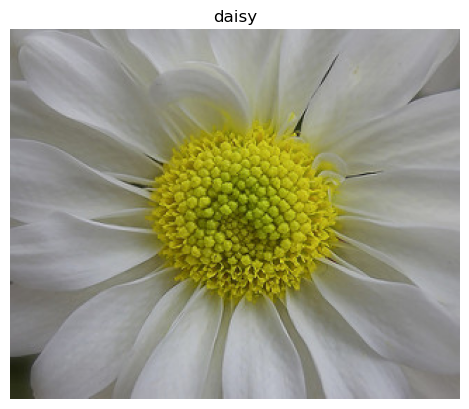

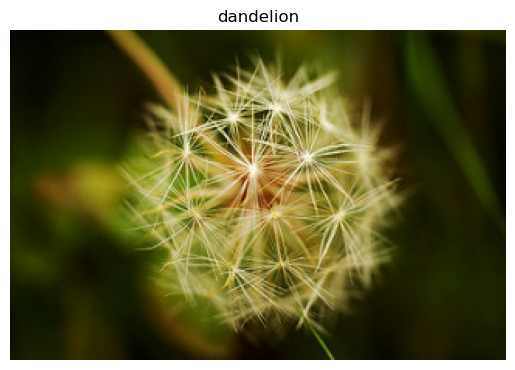

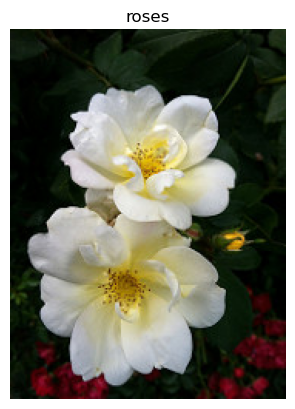

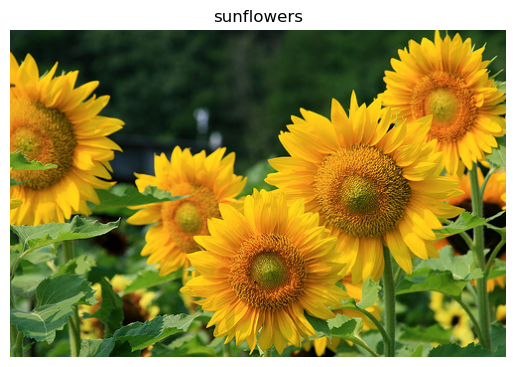

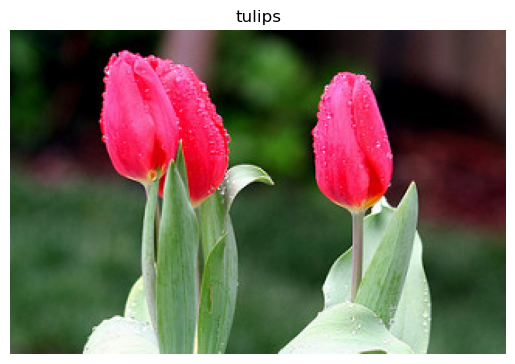

In [16]:

import os
import matplotlib.pyplot as plt
from PIL import Image

for cls in classes:
    images_names = os.listdir("flower_photos/" + cls)

    img = Image.open("flower_photos/" + cls + "/" + images_names[0])

    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")
    plt.show()


    

In [20]:
counts = {}
s=0
for cls in classes:
    counts[cls] = len(os.listdir(os.path.join(data_dir, cls)))
    s=counts[cls]+s
print(counts)
print("nombre total des photo ",s)

{'daisy': 633, 'dandelion': 898, 'roses': 641, 'sunflowers': 699, 'tulips': 799}
nombre total des photo  3670


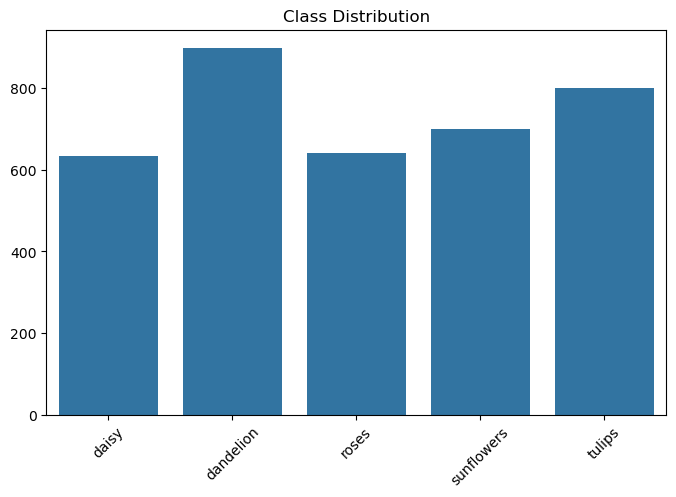

In [21]:
plt.figure(figsize=(8,5))
sns.barplot(x=list(counts.keys()), y=list(counts.values()))
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

In [52]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

base_dir = "flower_photos"

filepaths = []
labels = []

for class_name in os.listdir(base_dir):
    class_path = os.path.join(base_dir, class_name)
    
    for img in os.listdir(class_path):
        filepaths.append(os.path.join(class_path, img))
        labels.append(class_name)

df = pd.DataFrame({
    "filename": filepaths,
    "class": labels
})








train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df["class"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["class"], random_state=42)


from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filename",
    y_col="class",
    target_size=(150, 150),
    batch_size=32,
    class_mode="categorical"
)
val_gen = test_datagen.flow_from_dataframe(
    val_df,
    x_col="filename",
    y_col="class",
    target_size=(150, 150),
    batch_size=32,
    class_mode="categorical"
)
test_gen = test_datagen.flow_from_dataframe(
    test_df,
    x_col="filename",
    y_col="class",
    target_size=(150, 150),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

train_df.shape

Found 2569 validated image filenames belonging to 5 classes.
Found 550 validated image filenames belonging to 5 classes.
Found 551 validated image filenames belonging to 5 classes.


(2569, 2)

In [54]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Model

input_shape = Input((150, 150, 3))
conv1 = Conv2D(32, (3,3),strides=(2,2), activation="relu")(input_shape)
pool1 = MaxPooling2D((2,2))(conv1)
drop1 = Dropout(0.25)(pool1)

conv2 = Conv2D(64, (3,3), activation="relu")(drop1)
pool2 = MaxPooling2D((2,2))(conv2)
drop2 = Dropout(0.25)(pool2)

flat = Flatten()(drop2)

dense1 = Dense(64, activation="relu")(flat)
output = Dense(5, activation="softmax")(dense1)

model1 = Model(inputs=input_shape, outputs=output)
model1.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)          │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_21 (Conv2D)                   │ (None, 74, 74, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_21 (MaxPooling2D)      │ (None, 37, 37, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 37, 37, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_22 (Conv2D)                   │ (None, 35, 35, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_22 (MaxPooling2D)      │ (None, 17, 17, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 17, 17, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_11 (Flatten)                 │ (None, 18496)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 64)                  │       1,183,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,203,525 (4.59 MB)

 Trainable params: 1,203,525 (4.59 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 21s 244ms/step - accuracy: 0.3955 - loss: 1.3757 - val_accuracy: 0.4400 - val_loss: 1.2867
Epoch 2/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 20s 242ms/step - accuracy: 0.5146 - loss: 1.1539 - val_accuracy: 0.5582 - val_loss: 1.1230
Epoch 3/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 20s 244ms/step - accuracy: 0.5679 - loss: 1.0832 - val_accuracy: 0.5945 - val_loss: 1.0412
Epoch 4/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 20s 242ms/step - accuracy: 0.6022 - loss: 1.0064 - val_accuracy: 0.6073 - val_loss: 1.0462
Epoch 5/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 19s 236ms/step - accuracy: 0.6209 - loss: 0.9636 - val_accuracy: 0.5564 - val_loss: 1.2430
Epoch 6/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 19s 239ms/step - accuracy: 0.6438 - loss: 0.9312 - val_accuracy: 0.6491 - val_loss: 0.9107
Epoch 7/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 20s 242ms/step - accuracy: 0.6532 - loss: 0.8971 - val_accuracy: 0.6691 - val_loss: 0.8487
Epoch 8/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 20s 242ms/step - accuracy: 0.6691 - loss: 0.8583 - val_accu

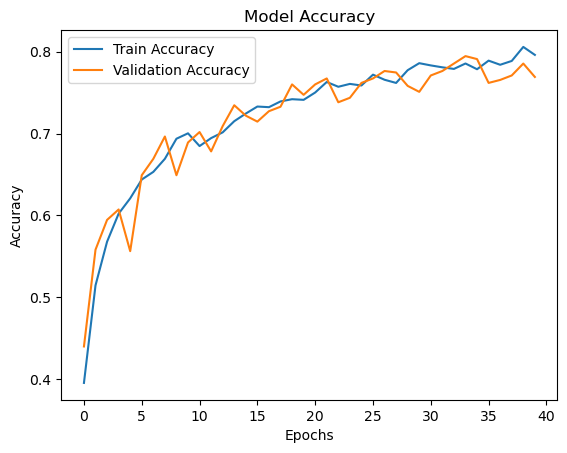

In [55]:
model1.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)
history = model1.fit(
    train_gen,
    validation_data=val_gen,
    epochs=40,callbacks=[early_stop]
)


import matplotlib.pyplot as plt







plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

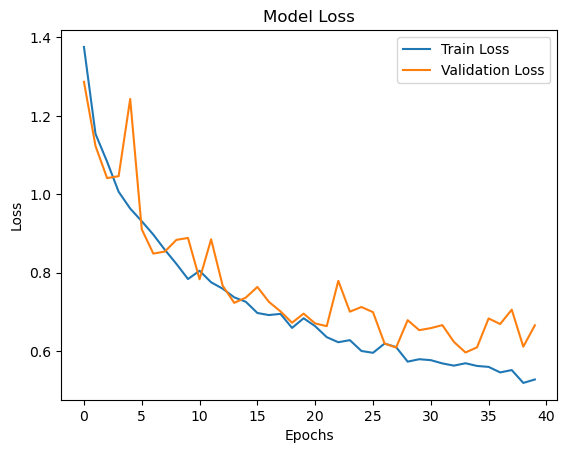

In [56]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)          │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_23 (Conv2D)                   │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_23 (MaxPooling2D)      │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_24 (Conv2D)                   │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_24 (MaxPooling2D)      │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_15 (Dropout)                 │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_25 (Conv2D)                   │ (None, 34, 34, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_25 (MaxPooling2D)      │ (None, 17, 17, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_16 (Dropout)                 │ (None, 17, 17, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_12 (Flatten)                 │ (None, 18496)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 64)                  │       1,183,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,240,453 (4.73 MB)

 Trainable params: 1,240,453 (4.73 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 32s 382ms/step - accuracy: 0.2386 - loss: 1.6394 - val_accuracy: 0.3345 - val_loss: 1.5633
Epoch 2/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 30s 378ms/step - accuracy: 0.3472 - loss: 1.4528 - val_accuracy: 0.4727 - val_loss: 1.3458
Epoch 3/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 29s 358ms/step - accuracy: 0.4675 - loss: 1.2386 - val_accuracy: 0.5327 - val_loss: 1.0973
Epoch 4/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 29s 355ms/step - accuracy: 0.5399 - loss: 1.1244 - val_accuracy: 0.5818 - val_loss: 1.0357
Epoch 5/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 29s 354ms/step - accuracy: 0.5738 - loss: 1.0539 - val_accuracy: 0.5745 - val_loss: 1.0093
Epoch 6/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 29s 361ms/step - accuracy: 0.5991 - loss: 0.9976 - val_accuracy: 0.5855 - val_loss: 0.9991
Epoch 7/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 29s 356ms/step - accuracy: 0.6251 - loss: 0.9285 - val_accuracy: 0.6382 - val_loss: 0.9099
Epoch 8/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 29s 360ms/step - accuracy: 0.6450 - loss: 0.9060 - val_accu

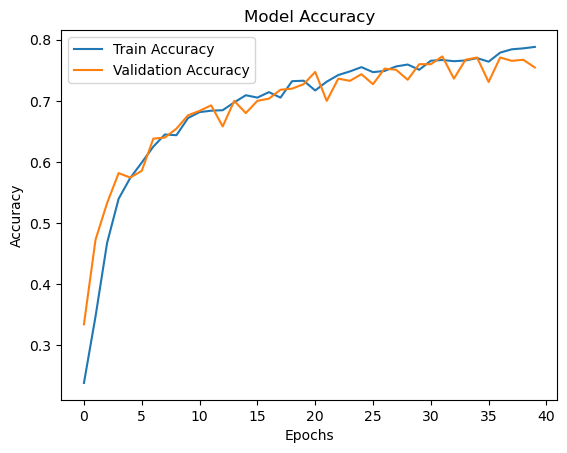

In [57]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Model

input_shape = Input((150, 150, 3))
conv1 = Conv2D(32, (3,3), activation="relu")(input_shape)
pool1 = MaxPooling2D((2,2))(conv1)
drop1 = Dropout(0.25)(pool1)

conv2 = Conv2D(64, (3,3), activation="relu")(drop1)
pool2 = MaxPooling2D((2,2))(conv2)
drop2 = Dropout(0.25)(pool2)

conv3 = Conv2D(64, (3,3), activation="relu")(drop2)
pool3 = MaxPooling2D((2,2))(conv3)
drop3 = Dropout(0.25)(pool3)


flat = Flatten()(drop3)

dense1 = Dense(64, activation="relu")(flat)
output = Dense(5, activation="softmax")(dense1)

model2 = Model(inputs=input_shape, outputs=output)
model2.summary()
model2.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)
history = model2.fit(
    train_gen,
    validation_data=val_gen,
    epochs=40,callbacks=[early_stop]
)


import matplotlib.pyplot as plt







plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

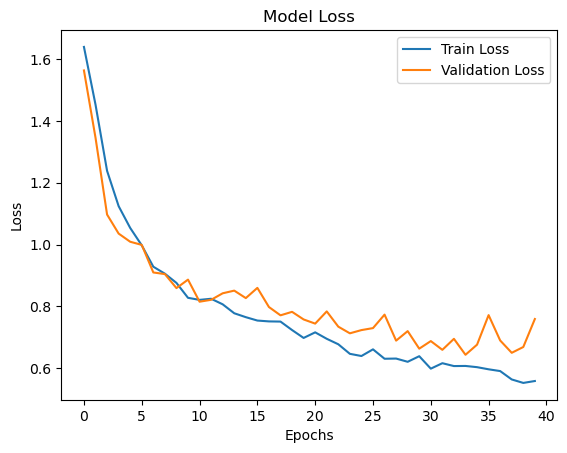

In [58]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()